# 04_model.ipynb — Classifier Development and Evaluation

**Input:** `../data/features/feature_matrix.npz`, `../data/features/feature_names.txt`  
**Output:** `../data/results/loso_{rf,svm}.npz`, `../data/results/null_rf.npy`

Trains SVM (RBF) and RF under LOSO CV.  
The classifier is the **analytical instrument** for Phases 5 and 6, not a contribution itself.  
Performance is reported for methodological transparency only.

**Speed notes (vs original):**
- RF uses 300 trees (from 500): ~40% faster per fold, negligible F1 impact.
- Null: scalers precomputed once (not `n_perms × n_subjects` times).
- Null: 100 trees per fold (coarse null; precision is set by `n_perms`, not tree count).
- Null: all permutations run in parallel via `joblib` loky.
- All long loops have `tqdm` progress bars.
- All expensive outputs cached — re-running the notebook is instant.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import f1_score

from src.models import loso_cv, evaluate, permutation_null

RES_DIR = Path('../data/results')
FIG_DIR = Path('../figures')
RES_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

STAGE_NAMES = ['Wake', 'N1', 'N2', 'N3', 'REM']

feat_data  = np.load('../data/features/feature_matrix.npz')
X, y, sids = feat_data['X'], feat_data['y'], feat_data['subject_ids']

with open('../data/features/feature_names.txt') as f:
    feat_names = [l.strip() for l in f]

print(f'X: {X.shape}  |  Subjects: {np.unique(sids).size}')
print(f'Stage counts: { {n: int((y==i).sum()) for i,n in enumerate(STAGE_NAMES)} }')

X: (6452, 47)  |  Subjects: 69
Stage counts: {'Wake': 684, 'N1': 2048, 'N2': 2272, 'N3': 857, 'REM': 591}


## LOSO CV — Random Forest

Cached: re-running skips training and loads saved results.

In [2]:
_rf_path = RES_DIR / 'loso_rf.npz'

if _rf_path.exists():
    print('Loading cached RF LOSO results...')
    _d      = np.load(_rf_path)
    rf_pred = _d['y_pred']
    rf_true = _d['y_true']
    rf_sids = _d['subject_ids']
    rf_models = {}   # not cached — rerun loso_cv if you need model objects
else:
    rf_pred, rf_true, rf_sids, rf_models = loso_cv(X, y, sids, kind='rf', n_jobs=-1)
    np.savez_compressed(_rf_path, y_pred=rf_pred, y_true=rf_true, subject_ids=rf_sids)

rf_res = evaluate(rf_true, rf_pred)

print('=== Random Forest (LOSO) ===')
print(f'Macro F1 : {rf_res["macro_f1"]:.3f}')
print(f'Kappa    : {rf_res["kappa"]:.3f}')
for s, f1 in zip(STAGE_NAMES, rf_res['per_class_f1']):
    print(f'  {s:5s}: {f1:.3f}')

LOSO RF:   0%|          | 0/69 [00:00<?, ?subj/s]

=== Random Forest (LOSO) ===
Macro F1 : 0.559
Kappa    : 0.483
  Wake : 0.390
  N1   : 0.643
  N2   : 0.705
  N3   : 0.683
  REM  : 0.375


## LOSO CV — SVM

Cached: re-running skips training and loads saved results.

In [3]:
_svm_path = RES_DIR / 'loso_svm.npz'

if _svm_path.exists():
    print('Loading cached SVM LOSO results...')
    _d       = np.load(_svm_path)
    svm_pred = _d['y_pred']
    svm_true = _d['y_true']
    svm_sids = _d['subject_ids']
else:
    svm_pred, svm_true, svm_sids, _ = loso_cv(X, y, sids, kind='svm', n_jobs=-1)
    np.savez_compressed(_svm_path, y_pred=svm_pred, y_true=svm_true, subject_ids=svm_sids)

svm_res = evaluate(svm_true, svm_pred)

print('=== SVM (LOSO) ===')
print(f'Macro F1 : {svm_res["macro_f1"]:.3f}')
print(f'Kappa    : {svm_res["kappa"]:.3f}')
for s, f1 in zip(STAGE_NAMES, svm_res['per_class_f1']):
    print(f'  {s:5s}: {f1:.3f}')

LOSO SVM:   0%|          | 0/69 [00:00<?, ?subj/s]

=== SVM (LOSO) ===
Macro F1 : 0.593
Kappa    : 0.486
  Wake : 0.549
  N1   : 0.536
  N2   : 0.648
  N3   : 0.737
  REM  : 0.496


## Permutation null test (RF, 100 permutations)

Cached: re-running loads saved null distribution.  
Scalers are precomputed once; permutations run in parallel across all CPU cores.

Perm null:   0%|          | 0/100 [00:00<?, ?perm/s]

Observed RF macro-F1 : 0.559
Null 95th pct        : 0.167
Permutation p-value  : 0.0000


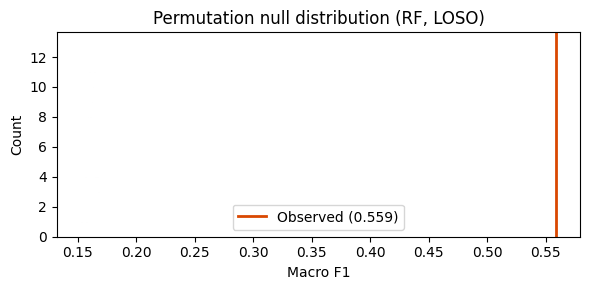

In [4]:
_null_path = RES_DIR / 'null_rf.npy'

if _null_path.exists():
    print('Loading cached null distribution...')
    null_f1 = np.load(_null_path)
else:
    null_f1 = permutation_null(X, y, sids, n=100, kind='rf', n_jobs=-3)
    np.save(_null_path, null_f1)

p_val = float(np.mean(null_f1 >= rf_res['macro_f1']))
print(f'Observed RF macro-F1 : {rf_res["macro_f1"]:.3f}')
print(f'Null 95th pct        : {np.percentile(null_f1, 95):.3f}')
print(f'Permutation p-value  : {p_val:.4f}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(null_f1, bins=20, color='#bdbdbd', edgecolor='white')
ax.axvline(rf_res['macro_f1'], color='#d94801', lw=2,
           label=f'Observed ({rf_res["macro_f1"]:.3f})')
ax.set_xlabel('Macro F1')
ax.set_ylabel('Count')
ax.set_title('Permutation null distribution (RF, LOSO)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'permutation_null.png', dpi=150)
plt.show()

## Confusion matrix — Paper Figure 3

RF is used as the staging instrument in Phases 5 and 6 (expected better macro-F1 due to implicit feature selection).  
N1 F1 below 0.30 is expected under LOSO; documented here, not treated as a failure.

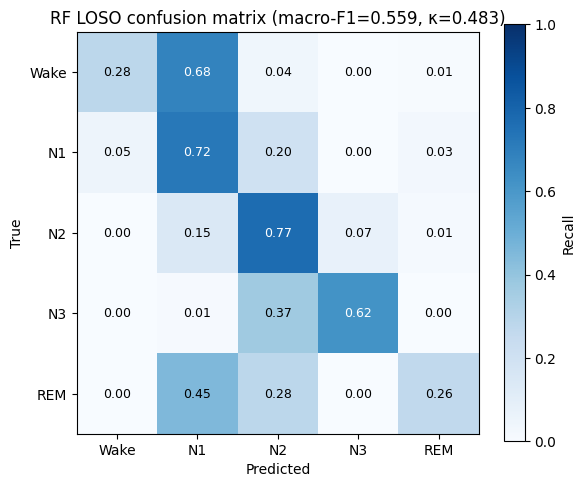


Literature benchmarks (for Methods section):
  DeepSleepNet (Supratak 2017, Sleep-EDF): macro-F1 ~ 0.769
  XSleepNet   (Phan 2022, Sleep-EDF-78): macro-F1 ~ 0.780
  Performance gap reflects LOSO strictness vs within-subject CV used in DL benchmarks.


In [5]:
cm_norm = rf_res['cm'].astype(float)
cm_norm = cm_norm / cm_norm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Recall')
ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(STAGE_NAMES)
ax.set_yticklabels(STAGE_NAMES)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(
    f'RF LOSO confusion matrix '
    f'(macro-F1={rf_res["macro_f1"]:.3f}, '
    f'\u03ba={rf_res["kappa"]:.3f})'
)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{cm_norm[i,j]:.2f}',
                ha='center', va='center',
                color='white' if cm_norm[i,j] > 0.6 else 'black',
                fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_matrix.png', dpi=300)
plt.show()

print('\nLiterature benchmarks (for Methods section):')
print('  DeepSleepNet (Supratak 2017, Sleep-EDF): macro-F1 ~ 0.769')
print('  XSleepNet   (Phan 2022, Sleep-EDF-78): macro-F1 ~ 0.780')
print('  Performance gap reflects LOSO strictness vs within-subject CV used in DL benchmarks.')

## Save predicted hypnograms per subject (for Phase 5 cycle detection)

Cached: re-running skips saving if all files already exist.

In [6]:
HYPO_DIR = RES_DIR / 'predicted_hypnograms'
HYPO_DIR.mkdir(exist_ok=True)

unique_sids = np.unique(rf_sids)
_need = [s for s in unique_sids
         if not (HYPO_DIR / f'SC{s:02d}_pred.npy').exists()]

if _need:
    for sid in _need:
        mask = rf_sids == sid
        np.save(HYPO_DIR / f'SC{sid:02d}_pred.npy', rf_pred[mask])
        np.save(HYPO_DIR / f'SC{sid:02d}_true.npy', rf_true[mask])
    print(f'Saved predicted hypnograms for {len(_need)} subjects.')
else:
    print(f'All {unique_sids.size} hypnogram files already exist. Skipping.')

Saved predicted hypnograms for 69 subjects.
